# Assignment 4 - Abramov Aleksandr. Question 3

Train both a standard Recurrent Neural Network (RNN) and a Long Short-Term
Memory (LSTM) network on a sequence prediction task (e.g., character-level generation using
2–3 sentences). Investigate the Long-Term Dependency problem by training both models for
varying numbers of epochs (e.g., 20, 50, and 100). Create a table comparing the accuracy and
prediction quality of both models at each epoch interval. Analyze how the LSTM mitigates the
vanishing gradient problem compared to the standard RNN. 

In [1]:
# The data was generated with Alice AI LLM using the following prompt:
# > Come up with a cohesive text in one paragraph of
# > around 1000 characters about RNN and LSTM
train_text = (
    "Recurrent Neural Networks (RNNs) are a class of neural networks "
    "designed to handle sequential data by maintaining a hidden "
    "state that captures information from previous inputs, enabling "
    "them to model temporal dependencies. However, standard RNNs "
    "struggle with long‑term dependencies due to the vanishing "
    "gradient problem, which hinders the flow of information over "
    "many time steps. To address this limitation, Long Short-Term "
    "Memory (LSTM) networks were introduced. LSTMs enhance RNNs with "
    "a more sophisticated memory cell and three key gates — input, "
    "forget, and output — that regulate the flow of information, "
    "allowing the network to selectively retain or discard data over "
    "long sequences. This architecture enables LSTMs to effectively "
    "capture long-range dependencies, making them highly effective "
    "for tasks like language modeling, speech recognition, and time "
    "series prediction, where context across distant elements is "
    "crucial."
)

test_text = (
    "While LSTMs are more complex and computationally intensive than "
    "basic RNNs, their superior performance on sequential tasks has "
    "made them a cornerstone of modern deep learning for sequence "
    "data."
)

In [2]:
# First, transform text into vectors with character-level embeddings

import numpy
import torch
import typing
import sklearn.preprocessing

ohe = sklearn.preprocessing.OneHotEncoder(sparse_output=False)

def encode_text(text: str, fit: bool = False):
    text = numpy.array(list(text.lower())).reshape(-1, 1)
    if fit:
        ohe.fit(text)
    return torch.tensor(ohe.transform(text), dtype=torch.float32)

def decode_text(logits: torch.Tensor):
    return "".join(ohe.inverse_transform(logits.numpy()).flatten())

train = encode_text(train_text, fit=True)
test = encode_text(test_text)

assert decode_text(train) == train_text.lower()
assert decode_text(test) == test_text.lower()

train.shape, test.shape

(torch.Size([932, 32]), torch.Size([193, 32]))

In [3]:
import numpy
import scipy.special
import sklearn.metrics

def estimate_quality(
    y_pred_logits: numpy.ndarray, y_true: numpy.ndarray
) -> dict:
    y_pred_proba = scipy.special.softmax(y_pred_logits, axis=1)
    y_pred = numpy.argmax(y_pred_proba, axis=1)
    labels = list(range(y_pred_proba.shape[1]))
    return {
        "Accuracy": sklearn.metrics.accuracy_score(y_true, y_pred),
        "AUC-ROC": sklearn.metrics.roc_auc_score(
            y_true, y_pred_proba, multi_class="ovo", labels=labels
        ),
        "Precision": sklearn.metrics.precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Recall": sklearn.metrics.recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "F1-score": sklearn.metrics.f1_score(
            y_true, y_pred, average="macro"
        ),
    }

def set_random_seed(seed: int = 42):
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

In [4]:
import tqdm

def make_batch(
    data: torch.Tensor,
    sequence_length: int,
    batch_size: typing.Optional[int] = None
):
    batch_size = batch_size or len(data)
    start_limit = len(data) - sequence_length - 1
    start_idxs = torch.randint(0, start_limit, (batch_size,))
    return torch.stack([
        data[idx:idx + sequence_length + 1] for idx in start_idxs
    ])

def train_eval(
    model: torch.nn.RNNBase,
    epochs: int = 500,
    sequence_length: int = 32,
    batch_size: int = 64
):
    set_random_seed(42)
    device = torch.device('cuda')

    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters())

    pbar = tqdm.trange(epochs)
    history = []
    for epoch in pbar:
        model.train()
        optimizer.zero_grad()
        batch = make_batch(train, sequence_length, batch_size)
        pred, state = model(batch[:, :-1, :].to(device))
        loss = torch.nn.functional.cross_entropy(
            pred, batch[:, 1:, :].to(device), reduction='mean'
        )
        loss.backward()
        optimizer.step()
        
        grad_min, grad_max = torch.inf, -torch.inf
        grad_sum, grad_count = 0, 0
        for param in model.parameters():
            grad_min = min(grad_min, param.grad.min())
            grad_max = max(grad_max, param.grad.max())
            grad_sum += param.grad.sum()
            grad_count += param.grad.numel()
        
        model.eval()
        with torch.no_grad():
            data = make_batch(test, sequence_length)
            pred, state = model(data[:, :-1, :].to(device))
            metrics = estimate_quality(
                pred.reshape(-1, data.shape[-1]).cpu().numpy(),
                data[:, 1:].reshape(-1, data.shape[-1]).argmax(dim=1)
            )
            metrics["Gradient (min)"] = grad_min.item()
            metrics["Gradient (max)"] = grad_max.item()
            metrics["Gradient (avg)"] = (grad_sum / grad_count).item()
            pbar.set_postfix(metrics)
            history.append(metrics)
    return history

In [5]:
import matplotlib.pyplot as plt

def draw_metric(rnn_history, lstm_history, metric: str, ax):
    ax.plot([epoch[metric] for epoch in rnn_history], label=f'RNN')
    ax.plot([epoch[metric] for epoch in lstm_history], label=f'LSTM')
    ax.set_title(f"{metric}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric)
    ax.legend()
    
@torch.no_grad()
def generate_text(model: torch.nn.Module, prompt: str, length: int):
    data = encode_text(prompt).unsqueeze(0)
    pred, state = model.cpu()(data)
    pred = pred[:, -1:, :]
    while len(prompt) < length:
        prompt += decode_text(pred.squeeze(0))
        pred = encode_text(prompt[-1]).unsqueeze(0)
        pred, state = model.cpu()(pred, state)
    return prompt

def run_experiment(sequence_length: int, batch_size: int):
    set_random_seed(42)

    rnn = torch.nn.RNN(
        input_size=32, hidden_size=32, batch_first=True
    )
    rnn_hist = train_eval(
        rnn, sequence_length=sequence_length, batch_size=batch_size
    )

    lstm = torch.nn.LSTM(
        input_size=32, hidden_size=32, batch_first=True
    )
    lstm_hist = train_eval(
        lstm, sequence_length=sequence_length, batch_size=batch_size
    )
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 7))
    draw_metric(rnn_hist, lstm_hist, "Accuracy", axes[0][0])
    draw_metric(rnn_hist, lstm_hist, "AUC-ROC", axes[0][1])
    draw_metric(rnn_hist, lstm_hist, "Precision", axes[0][2])
    draw_metric(rnn_hist, lstm_hist, "Recall", axes[1][0])
    draw_metric(rnn_hist, lstm_hist, "F1-score", axes[1][1])
    draw_metric(rnn_hist, lstm_hist, "Gradient (avg)", axes[1][2])
    fig.tight_layout()

    prompt = (
        "RNN and LSTM are the two neural network architectures "
        "commonly used for processing sequential data such as "
    )
    print('RNN:', generate_text(rnn, prompt, 256))
    print('LSTM:', generate_text(lstm, prompt, 256))

100%|██████████| 500/500 [01:26<00:00,  5.76it/s, Accuracy=0.00583, AUC-ROC=0.61, Precision=0.0174, Recall=0.00885, F1-score=0.00374, Gradient (min)=-0.00297, Gradient (max)=0.00322, Gradient (avg)=8.28e-7]  


RNN: RNN and LSTM are the two neural network architectures commonly used for processing sequential data such as demx.(tin‑, apxg.ldwen‑u,bweme .ngbwisf rgptmvdregwqpen‑ lyugate durgwqtenfongwqmedyngbtes.ong-tapdedencbling taedurkstwinf lowere .—tio- —rmgwqmen.o
LSTM: RNN and LSTM are the two neural network architectures commonly used for processing sequential data such as ---------------------i----b-i---b------b-----------i-b----------i-b---------i-b---------i-b---------i-b---------i-b---------i-b---------i-b---------i


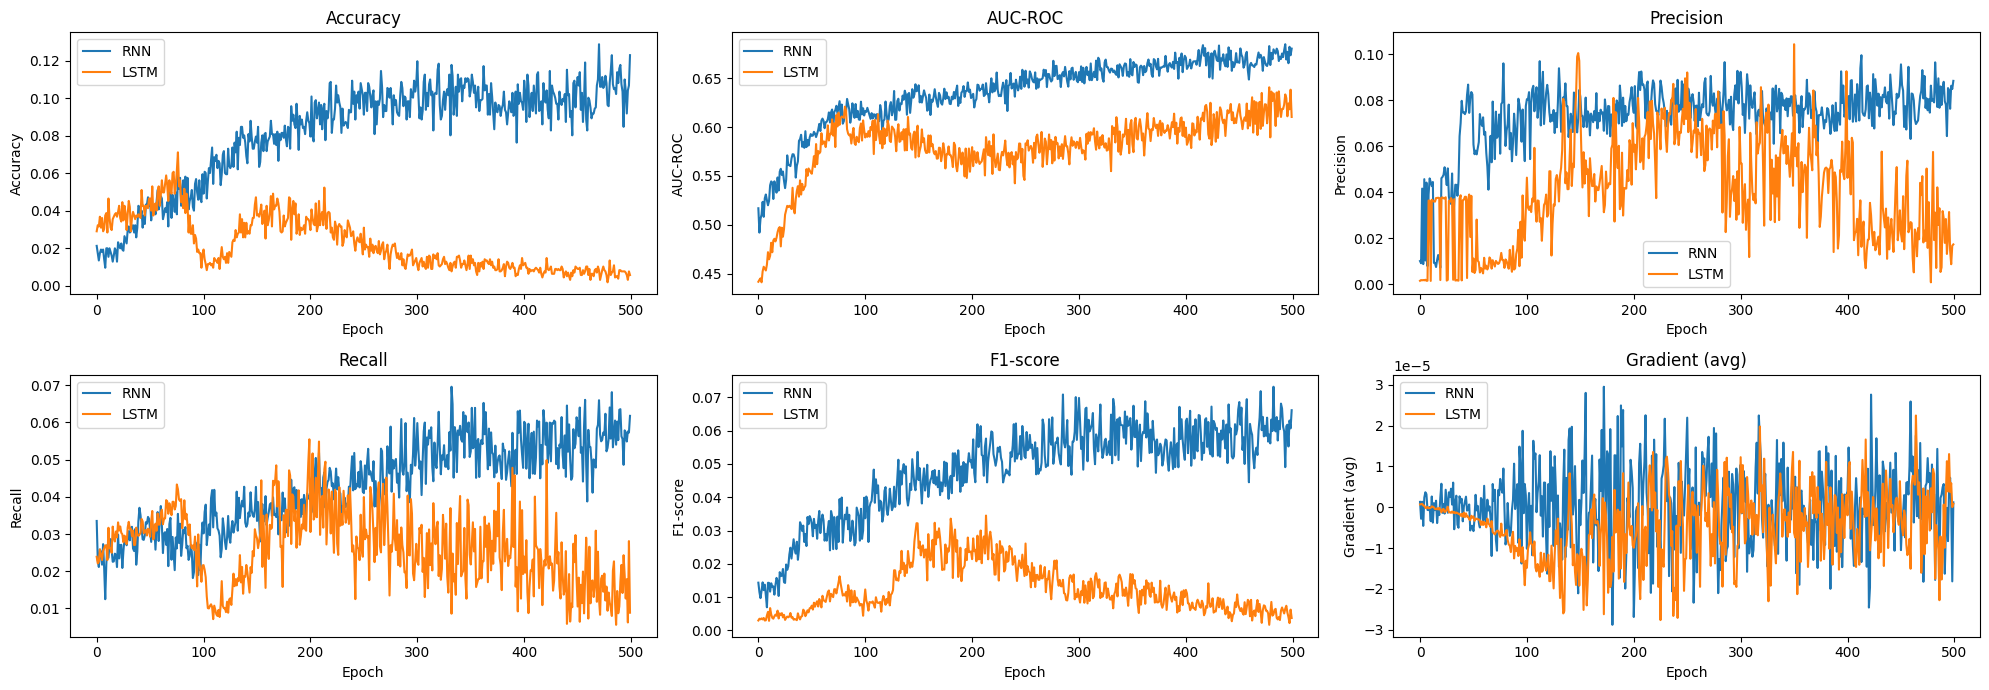

In [6]:
run_experiment(8, 128)

100%|██████████| 500/500 [01:57<00:00,  4.26it/s, Accuracy=0.0361, AUC-ROC=0.653, Precision=0.0966, Recall=0.0681, F1-score=0.0268, Gradient (min)=-0.0551, Gradient (max)=0.0666, Gradient (avg)=2.1e-5]      


RNN: RNN and LSTM are the two neural network architectures commonly used for processing sequential data such as xqpxqcxrciun‑.(them—dlyuses—.weues .(twes)dleseqtepe-.(bues —rxues—xusps)duem .lxhes.-t.ps)—uegestquegmemeueg‑.(tses alxuem .rrwes. .(p,esta(yu)matwe
LSTM: RNN and LSTM are the two neural network architectures commonly used for processing sequential data such as a‑‑tixxxxxxxkksksksl—in‑‑xxxxbboks sqqqnciens,abininxxxxbbkks sqqqngeq.qcani‑xxxxbbkss qqqning, aa‑ibxxxxbbkkss qqqning, a‑i‑xxxxbbksssqqqning, a‑‑tx


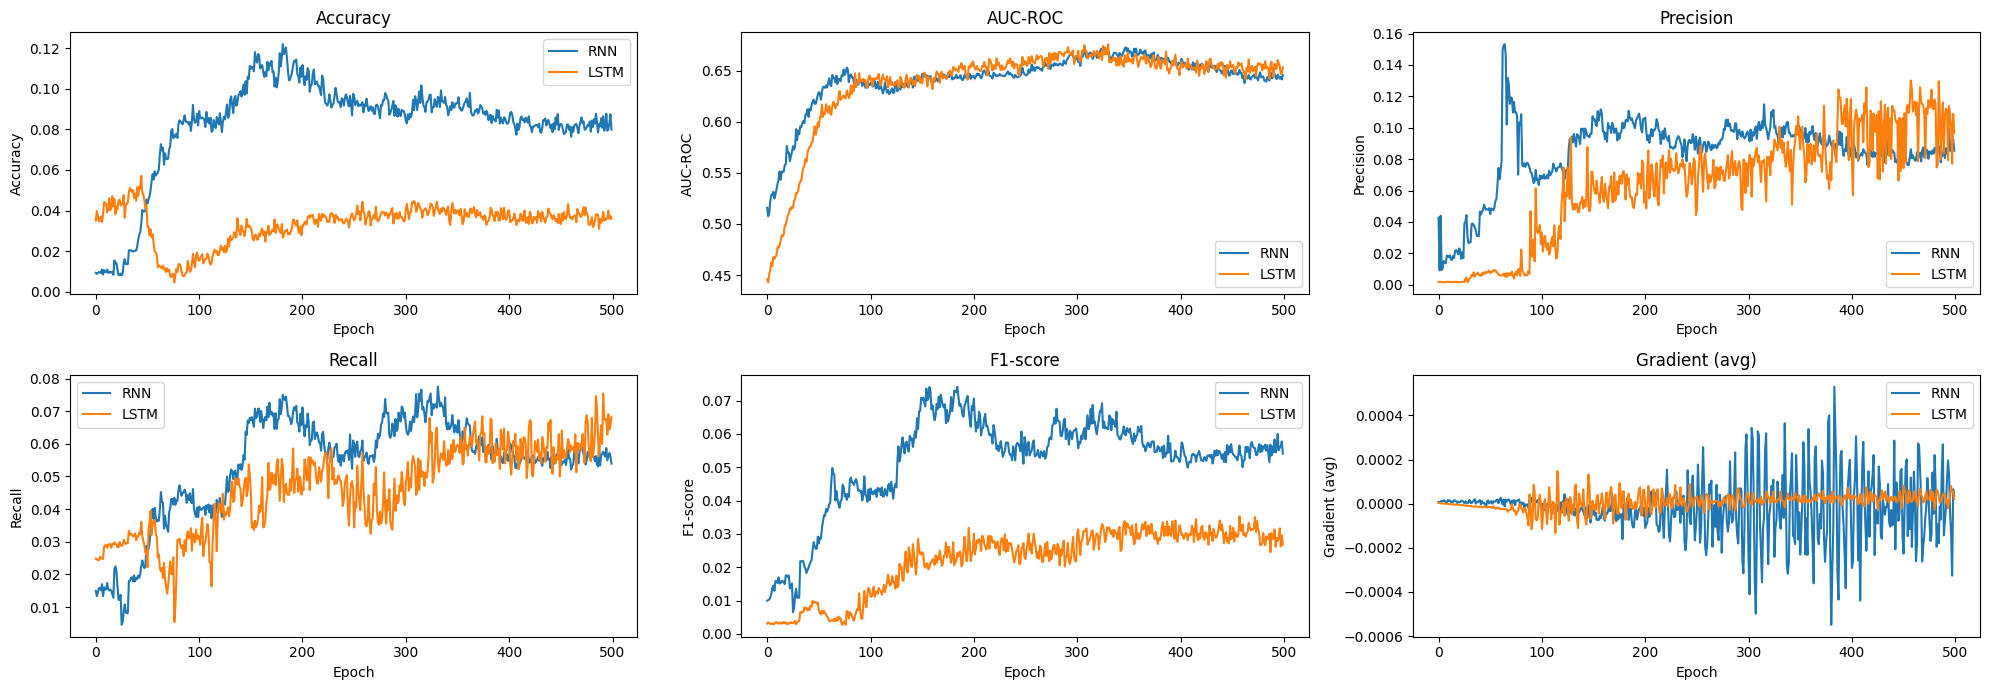

In [7]:
run_experiment(48, 128)

100%|██████████| 500/500 [02:17<00:00,  3.63it/s, Accuracy=0.0552, AUC-ROC=0.6, Precision=0.0809, Recall=0.0653, F1-score=0.0373, Gradient (min)=-0.117, Gradient (max)=0.103, Gradient (avg)=2.72e-6]        


RNN: RNN and LSTM are the two neural network architectures commonly used for processing sequential data such as siqp)peps—lyupe .—nxqtspepd—diupst —ncxqtepx-porm)dent -forkes.ltgqt —apxqs —xqxepepdiufp)—xo)epeg lyueg.—tipt-forket.-mepx-pepx)deq‑xqmxtop,ps.‑beps
LSTM: RNN and LSTM are the two neural network architectures commonly used for processing sequential data such as (qqqqqnn.s shataixtxx xbnsbsqnss.bstaxbbbnss—s—sttatxbblonss——inttx, bbbls—s—tttxxbblsssqqqn.s.sshataxblx xbbsqnsns.bshaxbbksqqqns.nstabbbkss——ttatxb


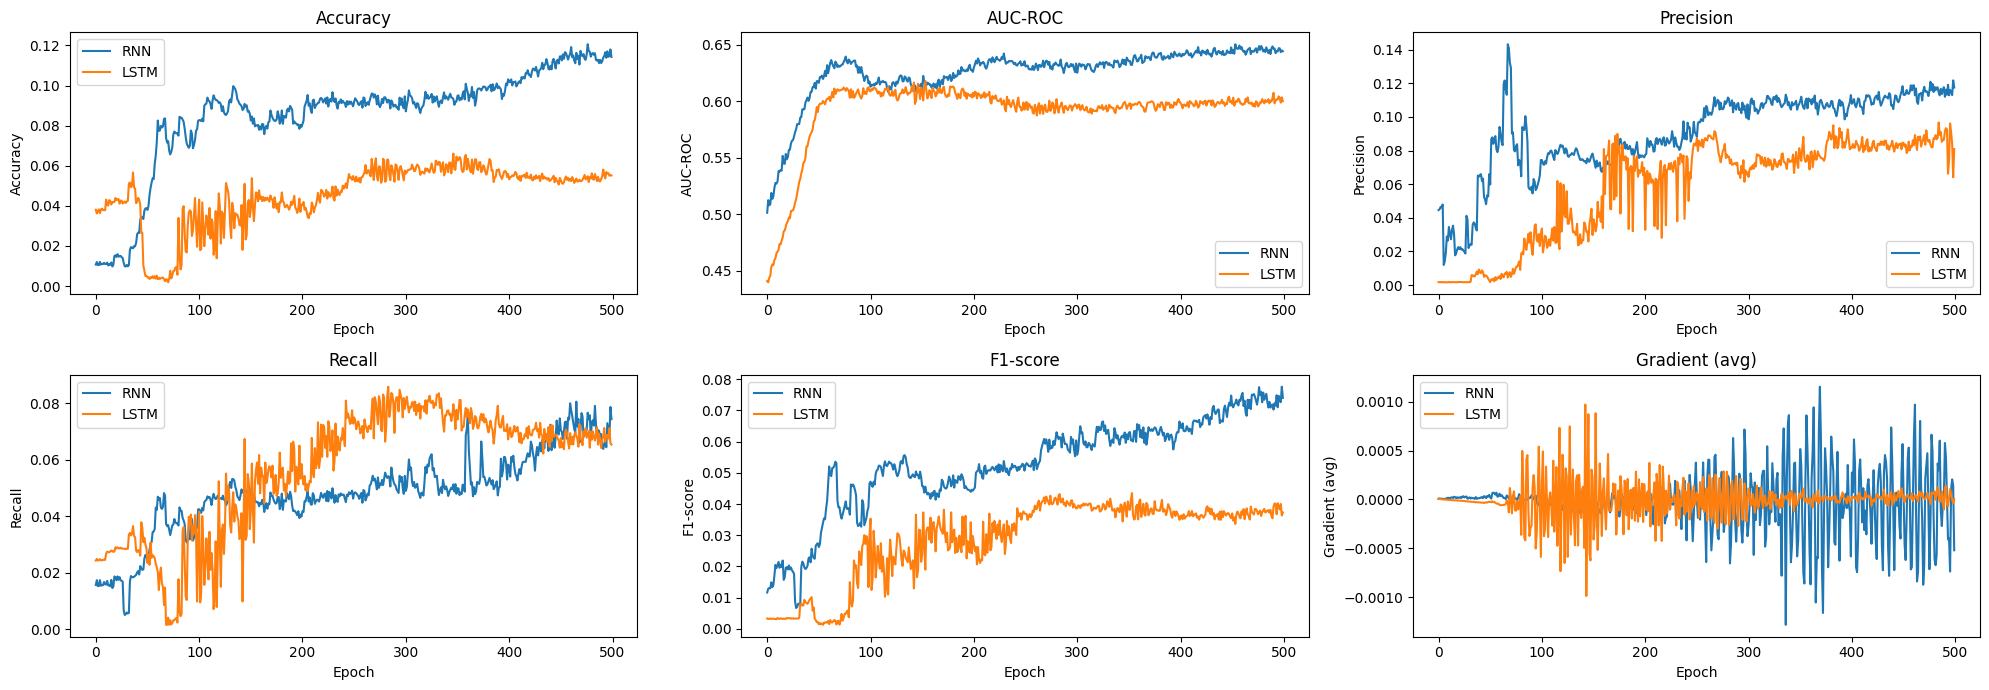

In [8]:
run_experiment(88, 128)

100%|██████████| 500/500 [02:52<00:00,  2.90it/s, Accuracy=0.0469, AUC-ROC=0.605, Precision=0.0646, Recall=0.0349, F1-score=0.0277, Gradient (min)=-0.316, Gradient (max)=0.368, Gradient (avg)=9.88e-5]          


RNN: RNN and LSTM are the two neural network architectures commonly used for processing sequential data such as xncis. thps) .(tspdepxgmapdbdepbups)d.npstqueps)——ci(t‑f,rw—rquepbups)—.ntepselxnc‑pep,byhvd.npupspq.xt(ps)—wepeps.xt(ps)—wapepsn‑—ephpq.—tyqps.lxu)s
LSTM: RNN and LSTM are the two neural network architectures commonly used for processing sequential data such as ‑‑‑‑‑‑‑r————st)dd)ddd.-t)d..bsbsaabiqqx,bsqqqs.s.)atabbbblksqqqq)————tt)) abbblkslggg‑‑‑‑‑‑‑‑t———— sthaxbblag————————tt)ddddddddd.-‑t)——— stasbblag——


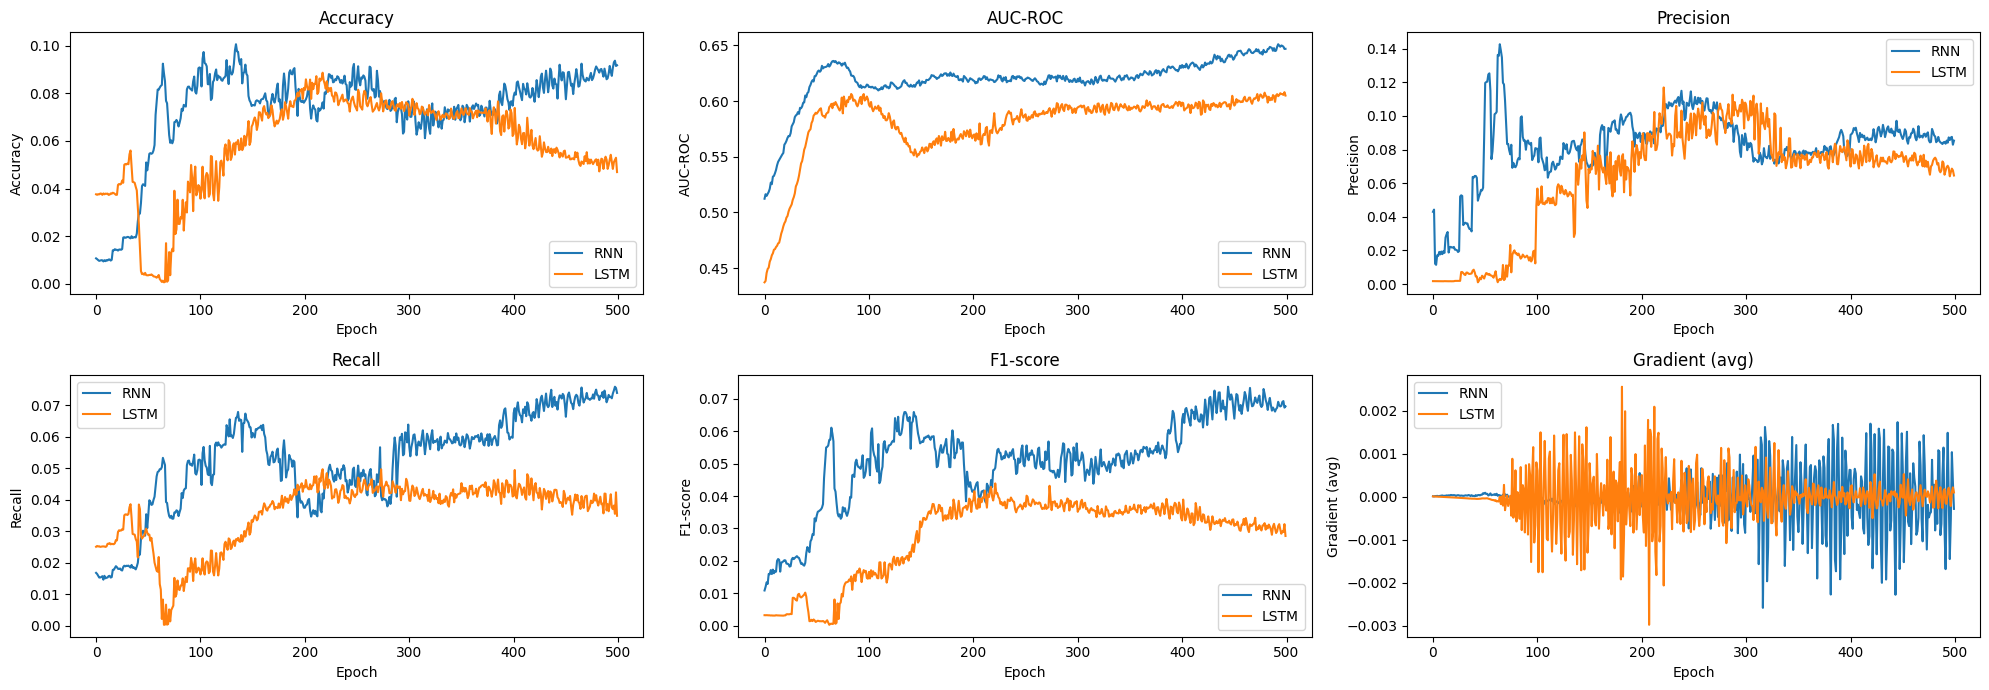

In [9]:
run_experiment(128, 128)

We trained a standard RNN and a LSTM network with different context sizes, ranging from 8 to 128, on a character-level text prediction task with a toy example. Expectedly, both models failed to learn anything meaningful due to the small amount of training data available. Nonetheless, one can explore some patterns on how these models behave.

In all experiments, RNN shows the same training processes, and achieves similar accuracy around $0.1$. Arguably, the prediction quality is slightly better for small contexts (8 characters in the first experiment), which is the indicator of a Long-Term Dependency problem inherent to RNNs. This architecture fails to learn distant patterns in the sequence, since the gradients tend to vanish during backpropagation through a lot of timesteps. In a plain RNN, norms of Jacobians are generally less than $1$, which leads to the gradients shrinking exponentially with the sequence length, making it hard to detect early characters that were the reasons for mistakes further in the sequence.

LSTM introduces cell state, which lets the information and gradients flow directly over longer sequences without multiplicative shrinking. As a result, LSTM better preserves signals from earlier timesteps, thus capturing more distant patterns in the data. This is demonstrated in the experiments in several ways:
- LSTM shows poor quality for short sequences (8 characters in the first experiment), yet achieves similar or even better results than the RNN for longer contexts;
- LSTM gradients are more stable, especially in later epochs, indicating better convergence;
- In all experiments, the training process of LSTM can be viewed in three parts. For the first several epochs, the accuracy increases, indicating quick detection of short dependencies. Then, the accuracy drops and slowly increases back up to its global maximum, which corresponds to the LSTM detecing most patterns in the data. Finally, the accuracy starts decreasing, indicaing overfitting: the model starts detecting too long depedencies, which are not actually present in the data.

Looking at the examples of the generated text, one also finds indications of the long-term dependency problem. RNN's output is mostly repetitive with similar sequences generated over and over. LSTM, on the other hand, produces a more various output, especially when trained with a longer sequence length.